# Phase 1: Parse Log với Drain3

## Load log file, đếm tổng số dòng

In [123]:

import os
import pandas as pd
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig

LOG_FILE_PATH = 'HDFS/HDFS_2k.log'


with open(LOG_FILE_PATH, "r", encoding="utf-8") as f:
        log_lines = [line.strip() for line in f if line.strip()]

total_lines = len(log_lines)
print(f"Tổng số dòng logs = {total_lines}") 



Tổng số dòng logs = 2000


## Parse toàn bộ log với Drain3 và Liệt kê tất cả templates, đếm số dòng mỗi template

In [124]:
config = TemplateMinerConfig()
config.drain_sim_th = 0.4 
config.drain_depth = 4  

# Khởi tạo Miner với cấu hình trên
miner = TemplateMiner(config=config)

for line in log_lines:
    result = miner.add_log_message(line)

# Tạo mảng lưu lại để export top 10 sau
extracted_templates = []

# Xem tất cả templates
print("All Templates")
for cluster in miner.drain.clusters:
    extracted_templates.append({
        "template_id": cluster.cluster_id,
        "template": cluster.get_template(),
        "count": cluster.size
    })
    
    print(f"  [{cluster.cluster_id}] (count={cluster.size}): {cluster.get_template()}")
    

All Templates
  [1] (count=311): <*> <*> <*> INFO dfs.DataNode$PacketResponder: PacketResponder <*> for block <*> terminating
  [2] (count=314): <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>
  [3] (count=292): <*> <*> <*> INFO dfs.DataNode$PacketResponder: Received block <*> of size <*> from <*>
  [4] (count=292): <*> <*> <*> INFO dfs.DataNode$DataXceiver: Receiving block <*> src: <*> dest: <*>
  [5] (count=115): <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: <*> <*>
  [6] (count=20): <*> <*> 13 INFO dfs.DataBlockScanner: Verification succeeded for <*>
  [7] (count=263): <*> <*> <*> INFO dfs.FSDataset: Deleting block <*> file <*>
  [8] (count=80): <*> <*> <*> INFO dfs.DataNode$DataXceiver: <*> Served block <*> to <*>
  [9] (count=80): <*> <*> <*> WARN dfs.DataNode$DataXceiver: <*> exception while serving <*> to <*>
  [10] (count=224): <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.delete: <

## Export top-10 templates ra results/top_templates.csv (columns: template_id, template, count)

In [125]:
os.makedirs("results", exist_ok=True)

# Chuyển thành dataframe cho dễ xử lý 
df_templates = pd.DataFrame(extracted_templates)

# Sắp xếp theo count 
df_templates = df_templates.sort_values(by="count", ascending=False)

# Lấy top 10 dòng đầu tiên có count cao nhất
top_10_df = df_templates.head(10)
top_10_df.to_csv("results/top_templates.csv", index=False, columns=["template_id", "template", "count"])

print("Đã export top 10 templates vào results/top_templates.csv ")

Đã export top 10 templates vào results/top_templates.csv 


## Tune drain_sim_th: thử 0.3, 0.5, 0.7 → ghi lại số template mỗi giá trị, chọn giá trị tốt nhất

In [126]:
drain_sim_th = [0.3, 0.5, 0.7]

for sim in drain_sim_th:
    config.drain_sim_th = sim

    # Khởi tạo Miner với cấu hình trên
    minerTune = TemplateMiner(config=config)

    for line in log_lines:
        result = minerTune.add_log_message(line)

    print(f"Số lượng templates với drain_sim_th = {sim} là {len(minerTune.drain.clusters)}")
    

Số lượng templates với drain_sim_th = 0.3 là 17
Số lượng templates với drain_sim_th = 0.5 là 21
Số lượng templates với drain_sim_th = 0.7 là 820


So sánh và chọn drain_sim_th tốt nhất 

Dựa vào file `HDFS_2k.log_templates.csv`, số templates là 14

Sau 4 lần tune drain_sim_th với 0.3, 0.5 và 0.7 thì với sim_th = 0.4, số lượng templets = 17, gần nhất với số lượng templates từ mẫu. Do đó chọn drain_sim_th = 0.3 là tốt nhất trong 3 lần tune

# Phase 2: Anomaly Detection trên Log

## Tạo template count time series (window 5 phút hoặc tùy dataset)

In [127]:
def create_template_timeseries(log_entries, window='5min'):
    """
    Biến parsed log thành time series per template.
    
    Args:
        log_entries: list of (timestamp, template_id) tuples
        window: aggregation window
    
    Returns:
        DataFrame: columns = template IDs, rows = time windows, values = count
    """
    df = pd.DataFrame(log_entries, columns=['timestamp', 'template_id'])
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Group by time window + template → count
    ts = df.groupby([pd.Grouper(key='timestamp', freq=window), 'template_id']).size()
    ts = ts.unstack(fill_value=0)  # pivot: rows=time, cols=template
    
    return ts


def extract_hdfs_timestamp(line):
    try:
        tokens = line.split()
        if len(tokens) >= 2:
            # Chuyển định dạng '081109 203518' -> '2008-11-09 20:35:18'
            return f"20{tokens[0][:2]}-{tokens[0][2:4]}-{tokens[0][4:]} {tokens[1][:2]}:{tokens[1][2:4]}:{tokens[1][4:]}"
    except Exception:
        pass
    return None

# Tạo mảng danh sách các cặp (timestamp, template_id)
log_entries = []

# 2. Sử dụng miner với drain_sim_th = 0.3 do 0.3 đang là threshold tốt nhất
config.drain_sim_th = 0.3
minerTune03 = TemplateMiner(config=config)
    
for line in log_lines:
    timestamp = extract_hdfs_timestamp(line)
    if not timestamp:
        continue
        
    # 2. Sử dụng miner với drain_sim_th = 0.3 do 0.3 đang là threshold tốt nhất
    result = minerTune03.add_log_message(line)
    template_id = result['cluster_id']
    
    log_entries.append((timestamp, template_id))


# Gọi hàm với windown = 5min
ts_dataframe = create_template_timeseries(log_entries, window='5min')

ts_dataframe

template_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
timestamp,,,,,,,,,,,,,,,,,
2008-11-09 20:35:00,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2008-11-09 20:40:00,2,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2008-11-09 20:45:00,1,1,2,3,0,0,0,0,0,0,0,0,0,0,0,0,0
2008-11-09 20:50:00,1,1,2,0,2,0,0,0,0,0,0,0,0,0,0,0,0
2008-11-09 20:55:00,0,3,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2008-11-11 10:00:00,2,3,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0
2008-11-11 10:05:00,1,1,1,3,0,0,0,0,0,0,0,0,0,0,0,0,0
2008-11-11 10:10:00,6,3,3,2,1,0,0,0,0,0,0,0,0,0,0,0,0


## Apply anomaly detector từ D1 (3σ hoặc Isolation Forest) trên template count và Detect: template nào spike bất thường? Template mới xuất hiện khi nào?

In [128]:
known_templates = set()  # templates đã thấy trong training period

def detect_new_template(result):
    """
    Detect khi Drain3 tạo template mới.
    Template mới = có gì đó mới xảy ra trong hệ thống.
    """
    template = result.get_template()
    if template not in known_templates:
        known_templates.add(template)
        return True, template  # NEW TEMPLATE — investigate!
    return False, template


for col in ts_dataframe.columns:
    series = ts_dataframe[col]
    
    # Tính mean và std cho template 
    mean_val = series.mean()
    std_val = series.std()
    
    # Anomaly threshold = Mean + 3 * Std
    if std_val > 0: 
        threshold = mean_val + 3 * std_val 
    else:
        mean_val + 5
    
    # Tìm các khung giờ có số lượng log vượt quá ngưỡng
    anomalies = series[series > threshold]
    
    if len(anomalies) > 0:
        # Tìm thời điểm lần đầu sinh ra log trong history
        first_active_time = series[series > 0].index.min()
        
        # In header SPIKE 
        has_printed_spike_header = False
        
        for timestamp, count in anomalies.items():
            if timestamp == first_active_time:
                print(f"NEW TEMPLATE {col}")
                print(f"- Xuất hiện lần đầu lúc {timestamp}")
                print(f"- Số lần xuất hiện templates trong khung giờ này: {count}")
                print()
                

            else:
                if not has_printed_spike_header:
                    print(f"Template {col} phát hiện anomaly (SPIKE) theo 3sigma = {threshold:.2f}:")
                    has_printed_spike_header = True
                    
                print(f"- Vào lúc {timestamp} - Số lần template xuất hiện: {count} - Normal xuất hiện {mean_val:.2f}")
                
        if has_printed_spike_header:
            print()

Template 1 phát hiện anomaly (SPIKE) theo 3sigma = 4.94:
- Vào lúc 2008-11-10 01:40:00 - Số lần template xuất hiện: 5 - Normal xuất hiện 1.02
- Vào lúc 2008-11-10 23:05:00 - Số lần template xuất hiện: 5 - Normal xuất hiện 1.02
- Vào lúc 2008-11-11 02:55:00 - Số lần template xuất hiện: 5 - Normal xuất hiện 1.02
- Vào lúc 2008-11-11 07:20:00 - Số lần template xuất hiện: 5 - Normal xuất hiện 1.02
- Vào lúc 2008-11-11 07:30:00 - Số lần template xuất hiện: 5 - Normal xuất hiện 1.02
- Vào lúc 2008-11-11 08:40:00 - Số lần template xuất hiện: 6 - Normal xuất hiện 1.02
- Vào lúc 2008-11-11 10:10:00 - Số lần template xuất hiện: 6 - Normal xuất hiện 1.02

Template 2 phát hiện anomaly (SPIKE) theo 3sigma = 4.93:
- Vào lúc 2008-11-10 12:30:00 - Số lần template xuất hiện: 5 - Normal xuất hiện 1.03
- Vào lúc 2008-11-10 15:05:00 - Số lần template xuất hiện: 5 - Normal xuất hiện 1.03
- Vào lúc 2008-11-11 03:00:00 - Số lần template xuất hiện: 5 - Normal xuất hiện 1.03
- Vào lúc 2008-11-11 09:55:00 - Số 

## Nếu dataset có label (HDFS): tính precision/recall của log-based anomaly detection

In [129]:
import re

LABEL_FILE_PATH = 'HDFS/anomaly_label.csv'

df_labels = pd.read_csv(LABEL_FILE_PATH)

# Mapping thành dictionary để tra cứu nhanh
ground_truth = dict(zip(df_labels['BlockId'], df_labels['Label']))

# Xác định các window bị báo anomaly
anomaly_windows = set()

for col in ts_dataframe.columns:
    series = ts_dataframe[col]
    mean_val = series.mean()
    std_val = series.std()
    
    threshold = (mean_val + 3 * std_val) if std_val > 0 else (mean_val + 5)
    
    anomalies = series[series > threshold]
    for timestamp in anomalies.index:
        anomaly_windows.add(timestamp)
        
# Extract block id của các line bị báo anomaly
def extract_block_id(line):
    match = re.search(r'(blk_-?\d+)', line)
    return match.group(1) if match else None

predicted_anomaly_blocks = set()

# Quét lại danh sách logs, tìm block id bị 3o báo aomaly
for line in log_lines:
    t_stamp = extract_hdfs_timestamp(line)
    if not t_stamp:
        continue
        
    dt = pd.to_datetime(t_stamp)
    time_bucket = dt.floor('5min')
    
    if time_bucket in anomaly_windows:
        block_id = extract_block_id(line)
        if block_id and block_id in ground_truth:
            predicted_anomaly_blocks.add(block_id)


# Danh sách blpock bị lỗi thật sự thừ anomaly label file
actual_anomaly_blocks = set([blk for blk, lbl in ground_truth.items() if lbl == 'Anomaly'])

# Tính TP
tp = len(predicted_anomaly_blocks.intersection(actual_anomaly_blocks))

# Tính FP
fp = len(predicted_anomaly_blocks - actual_anomaly_blocks)

# Tính FN
fn = len(actual_anomaly_blocks - predicted_anomaly_blocks)

# Tính Precision, Recall
if (tp + fp) > 0:
    precision = tp / (tp + fp) 
else:
    precicion = 0

if (tp + fn) > 0:
    recall = tp / (tp + fn)
else:
    recall = 0

# Precision và Recall
print(f"- Precision: {precision:.3}")
print(f"- Recall: {recall:.3}")

- Precision: 0.0495
- Recall: 0.00267


# Phase 3: Embedding + Cross-signal

## TF-IDF trên templates → tính similarity matrix → tìm template clusters

In [130]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

templates = []
template_ids = []


for cluster in minerTune03.drain.clusters:
    template_ids.append(cluster.cluster_id)
    templates.append(cluster.get_template())

# 1. TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(templates)

# 2. Similarity matrix
sim_matrix = cosine_similarity(tfidf_matrix)

# Nếu độ tương đồng >= 0.3 thì gom chung cluster 
similarity_threshold = 0.3


clusters = []
visited = set()

# Gom template tương đồng
for i in range(len(templates)):
    if i in visited:
        continue
        
    current_cluster = [i]
    queue = [i]
    visited.add(i)
    
    while queue:
        curr = queue.pop(0)
        
        for neighbor in range(len(templates)):
            if neighbor not in visited:
                
                if sim_matrix[curr][neighbor] >= similarity_threshold:
                    visited.add(neighbor)
                    current_cluster.append(neighbor)
                    queue.append(neighbor)
                    
    clusters.append(current_cluster)


for cluster_idx, template_indices in enumerate(clusters):
    print(f"Cluster {cluster_idx + 1} gồm có {len(template_indices)} templates:")
    for idx in template_indices:
        print(f"- Template {idx}: {templates[idx]}")
    print()

Cluster 1 gồm có 6 templates:
- Template 0: <*> <*> <*> INFO dfs.DataNode$PacketResponder: PacketResponder <*> for block <*> terminating
- Template 2: <*> <*> <*> INFO dfs.DataNode$PacketResponder: Received block <*> of size <*> from <*>
- Template 12: 081111 <*> <*> INFO dfs.DataNode$DataXceiver: Received block <*> src: <*> dest: <*> of size 67108864
- Template 3: <*> <*> <*> INFO dfs.DataNode$DataXceiver: Receiving block <*> src: <*> dest: <*>
- Template 7: <*> <*> <*> INFO dfs.DataNode$DataXceiver: <*> Served block <*> to <*>
- Template 8: <*> <*> <*> WARN dfs.DataNode$DataXceiver: <*> exception while serving <*> to <*>

Cluster 2 gồm có 4 templates:
- Template 1: <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>
- Template 4: <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: <*> <*>
- Template 9: <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.delete: <*> is added to invalidSet of <*>
- Templat

## Inject 1 dòng log “lạ” (tự viết, khác tất cả template) → Drain3 tạo new template → detect

In [134]:
known_templates = set() 

def detect_new_template(result_dict):
    template = result_dict.get('template_mined')
    
    if template not in known_templates:
        known_templates.add(template)
        return True, template  # NEW TEMPLATE - investigate!
    return False, template

for line in log_lines:
    result = minerTune03.add_log_message(line)
    detect_new_template(result)


# Inject log template mới 
injected_anomaly_log = "081110 143522 INFO dfs.DataNode$PacketResponder: CRITICAL SECURITY WARNING: Unauthorized root access detected from IP=192.168.1.99"

# Miner phân tích inject log 
parse_result = minerTune03.add_log_message(injected_anomaly_log)

is_anomaly, detected_template = detect_new_template(parse_result)

if is_anomaly:
    print(f"- NEW TEMPLATE được phát hiện {parse_result['cluster_id']}")
    print(f"- Cấu trúc template: {detected_template}")
else:
    print("Normal template")

- NEW TEMPLATE được phát hiện 18
- Cấu trúc template: 081110 143522 INFO dfs.DataNode$PacketResponder: CRITICAL SECURITY WARNING: Unauthorized root access detected from IP=192.168.1.99


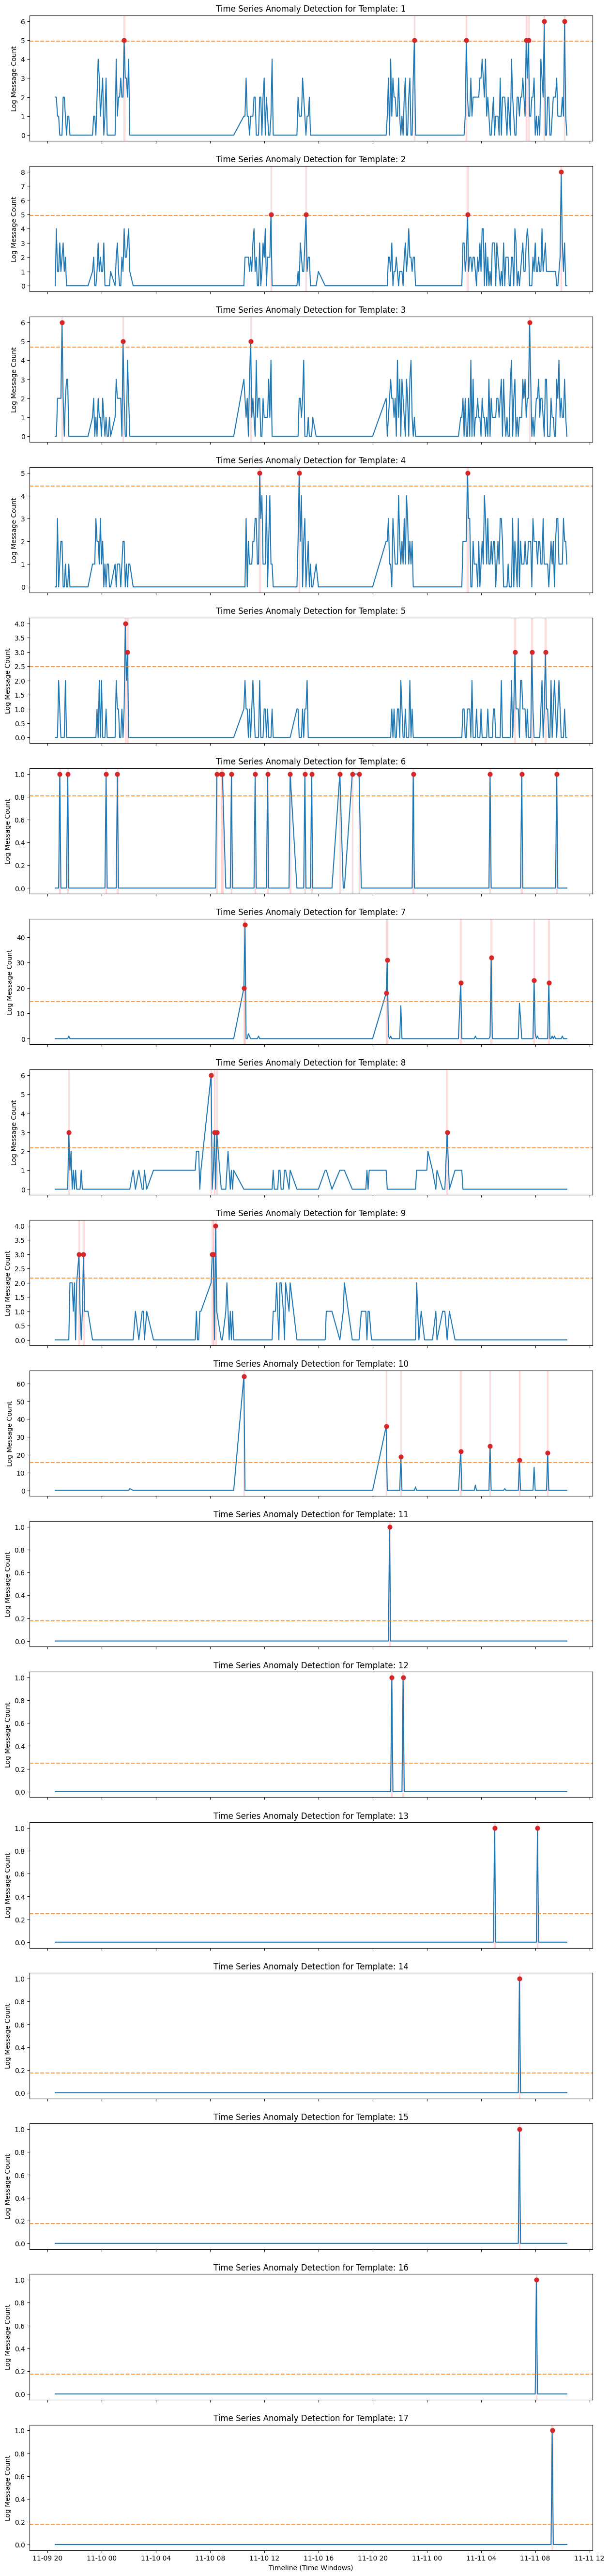

In [139]:
import matplotlib.pyplot as plt
import pandas as pd


top_templates_to_plot = ts_dataframe.columns[:17]


fig, axes = plt.subplots(nrows=len(top_templates_to_plot), ncols=1, figsize=(15, 4 * len(top_templates_to_plot)), sharex=True)


if len(top_templates_to_plot) == 1:
    axes = [axes]

for idx, col in enumerate(top_templates_to_plot):
    series = ts_dataframe[col]
    ax = axes[idx]
    

    mean_val = series.mean()
    std_val = series.std()
    threshold = (mean_val + 3 * std_val) if std_val > 0 else (mean_val + 5)
    

    ax.plot(series.index, series.values, label=f'Log Count ({col})', color='tab:blue', linewidth=1.5)

    ax.axhline(y=threshold, color='tab:orange', linestyle='--', alpha=0.8, label=f'3-Sigma Threshold ({threshold:.2f})')

    anomalies = series[series > threshold]

    if not anomalies.empty:
        ax.scatter(anomalies.index, anomalies.values, color='tab:red', s=40, zorder=5, label='Anomaly Detected (Spike)')

        for anomaly_time in anomalies.index:
            ax.axvspan(anomaly_time - pd.Timedelta(minutes=2.5), anomaly_time + pd.Timedelta(minutes=2.5), color='red', alpha=0.1)

    ax.set_title(f'Time Series Anomaly Detection for Template: {col}', fontsize=12)
    ax.set_ylabel('Log Message Count', fontsize=10)

axes[-1].set_xlabel('Timeline (Time Windows)', fontsize=10)

plt.savefig('ts_anomaly_plot.png', dpi=300, bbox_inches='tight')

plt.show()